# GBF-CD: Graph-Based Data Fusion for Change Detection — minimal reproduction

**Paper:** Jimenez-Sierra, D. A.; Benítez-Restrepo, H. D.; Vargas-Cardona, H. D.; Chanussot, J.
*Graph-Based Data Fusion Applied to: Change Detection and Biomass Estimation in Rice Crops.*
**Remote Sensing** 2020, 12(17), 2683. [DOI 10.3390/rs12172683](https://doi.org/10.3390/rs12172683)

**Author code (pinned):** https://github.com/DavidJimenezS/GBF-CD @ commit `2c11fd15ae5371c6ef9a3b48a1c8489f85bcb116` (`Python Version/generate_nystrom_graph.py`)

**Scope of this notebook (partial demonstration):** run the authors' own Python implementation of the change-detection branch (GBF-CD) on **one** included dataset — `SF_dataset.mat` (San Francisco flood scene, 275×400, ERS-2 SAR, pre 2003-08-10 / post 2004-05-16, per paper Tables 1 and 4) — and reproduce the paper's evaluation metrics (`MA`, `FA`, Precision, Recall, Cohen's kappa, `OE`, from `Functions/cohensKappa.m`) plus the green/blue/red error label map against the author-supplied reference change map.

**Out of scope:** the rice biomass branch (no public code or UAV images/labels exist), the 14-scene benchmark, and the KI / rR-EM / rrR-EM / U-CD-HPT baselines. A one-example run does not verify the paper's dataset-level results.

**No trained weights are involved:** GBF-CD is a semi-unsupervised graphical method; the only parameter is the number of samples `ns` (paper Table 4: San Francisco `ns = 4`). The kernel width is computed internally by the authors' code.

**Execution status:** executed on a Google Colab **CPU** runtime (no GPU is needed — the core operation is a Nyström eigendecomposition of a 9×9 matrix).

**日本語:** このノートブックは、論文の著者自身が公開した Python 実装（コミット固定）をそのまま実行し、論文に含まれるデータセットのうち `SF_dataset.mat`（サンフランシスコ洪水シーン）1 例に対する変化検出を再現します。学習済み重みは不要で、唯一のパラメータは論文 Table 4 のサンプル数 `ns=4` です。バイオマス推定ブランチは公開データが存在しないため対象外です。

**Faithfulness note:** the notebook uses the authors' pinned Python file verbatim and applies only small, individually documented compatibility fixes (listed below). It does not re-implement the algorithm.

**Citation requirement (authors' README):** if you use the datasets and/or code, cite the paper (BibTeX in the repository README).

## 1. Runtime selection

**Select `Runtime → Change runtime type → CPU` (standard).** No GPU is required: the method reduces to distance matrices of size (110000 × 9) and a 9×9 eigendecomposition. Expected duration is a few minutes end-to-end; total downloads are well under 1 MB (one 111,493-byte `.mat` dataset plus one 8,575-byte source file).

**日本語:** ランタイムは **CPU** を選択してください。GPU は不要です（9×9 行列の固有値分解が中心）。全体の所要時間は数分、ダウンロードは 1 MB 未満です。

In [ ]:
# Environment check: report the preinstalled scientific stack before any download.
import sys, importlib

print("Python", sys.version.split()[0])
for pkg in ["numpy", "scipy", "cv2", "skimage", "matplotlib", "sklearn", "pandas"]:
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg}: {getattr(m, '__version__', 'unknown')}")
    except ImportError:
        print(f"{pkg}: MISSING")

Python 3.13.16
numpy: 2.1.3
scipy: 1.16.3
cv2: 5.0.0
skimage: 0.25.2
matplotlib: 3.10.0


sklearn: 1.6.1
pandas: 2.2.3


**What this cell does:** imports the scientific stack and prints versions. `cv2` (OpenCV) is used by the authors' code for Otsu thresholding and `skimage` for byte-scale conversion; both are preinstalled on standard Colab, but the next cell guards the rare missing case.

**日本語:** 科学計算ライブラリのバージョンを確認します。`cv2`（大津法しきい値処理）と `skimage` は著者コードが使用します。通常は Colab にプリインストール済みです。

In [ ]:
# Guard: install OpenCV only if it is genuinely absent (standard Colab has it).
import importlib.util

if importlib.util.find_spec("cv2") is None:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"], check=True)
    print("installed opencv-python-headless")
import cv2
print("cv2 OK:", cv2.__version__)

cv2 OK: 5.0.0


## 2. Data acquisition (pinned)

**What this cell does:** downloads `SF_dataset.mat` — one of the change-detection datasets the authors ship inside the paper's repository — from the **exact pinned commit** and verifies it before use: expected size **111,493 bytes** and expected **git blob SHA-1** `915b25a4385ee130d1ee627e4b882fe8f0fdef63` (from the repository tree at that commit), plus a rejection check for HTML error pages. The file stays under `/content` on the Colab VM.

**日本語:** 論文リポジトリに同梱された `SF_dataset.mat` をコミット固定の URL からダウンロードし、サイズと git blob ハッシュで完全性を検証します。ファイルは Colab VM 内の `/content` にのみ置かれます。

In [ ]:
import urllib.request, hashlib

COMMIT = "2c11fd15ae5371c6ef9a3b48a1c8489f85bcb116"
REPO_RAW = f"https://raw.githubusercontent.com/DavidJimenezS/GBF-CD/{COMMIT}"

DATASET_URL = f"{REPO_RAW}/Data/SF_dataset.mat"
DATASET_SIZE = 111493
DATASET_BLOB_SHA = "915b25a4385ee130d1ee627e4b882fe8f0fdef63"

dst = "/content/SF_dataset.mat"
urllib.request.urlretrieve(DATASET_URL, dst)
raw = open(dst, "rb").read()

assert len(raw) == DATASET_SIZE, f"size mismatch: got {len(raw)} bytes"
assert not raw.lstrip().startswith(b"<!DOCT"), "refusing HTML error page"
git_blob = hashlib.sha1(b"blob %d\x00" % len(raw) + raw).hexdigest()
assert git_blob == DATASET_BLOB_SHA, f"git blob SHA mismatch: {git_blob}"

print(f"SF_dataset.mat verified: {len(raw)} bytes, git blob {git_blob}")
print("sha256:", hashlib.sha256(raw).hexdigest())

SF_dataset.mat verified: 111493 bytes, git blob 915b25a4385ee130d1ee627e4b882fe8f0fdef63
sha256: 1ca3198c7e58a5bdfb671dfdc6389c6e481baeae5e081a060d67a0adcbe0f54c


**What this cell does:** downloads the authors' Python implementation `generate_nystrom_graph.py` (class `GBF_CD`) from the same pinned commit and stores it under `/content`. This is the verbatim author file (8,575 bytes); its role in the paper's pipeline: graph construction → fusion → Nyström eigenvectors → mutual-information selection → change map.

**日本語:** 著者自身の Python 実装 `generate_nystrom_graph.py`（クラス `GBF_CD`）を同一コミットから取得し、`/content` に保存します。中身は一切改変しない生のファイルです。

In [ ]:
CODE_URL = f"{REPO_RAW}/Python%20Version/generate_nystrom_graph.py"

code_path = "/content/generate_nystrom_graph.py"
with urllib.request.urlopen(CODE_URL, timeout=60) as r:
    src = r.read()

assert b"class GBF_CD" in src, "unexpected file content"
with open(code_path, "wb") as f:
    f.write(src)

print(f"generate_nystrom_graph.py saved: {len(src)} bytes, sha256 {hashlib.sha256(src).hexdigest()[:16]}…")

generate_nystrom_graph.py saved: 8575 bytes, sha256 dee28ef95bf88329…


## 3. Documented compatibility fixes (before import)

The author file is used verbatim **except** for three small, evidence-backed fixes:

1. **MI loop bound (fidelity fix toward the MATLAB original).** In `Functions/gbf_cd.m` the mutual-information loop runs over the *actual* number of sampled eigenvectors (`for i = 2:n` with `n = length(locations)`). The Python port loops `range(1, self.n_samples)` instead. For San Francisco, grid sampling of `ns = 4` on a 275×400 image yields **9 actual samples** (3×3 grid), so the ported loop would silently test only 3 of 9 eigenvectors. We bind the loop to the actual sample count, matching MATLAB.
2. **`numpy.matlib` import.** The authors import `repmat` from `numpy.matlib`, a legacy module that may be unavailable under NumPy ≥ 2. We keep the original import when it works and only substitute an equivalent `np.tile` shim when it does not (`repmat` is used exclusively on column vectors tiled along columns, where `np.tile` is exactly equivalent).
3. **Numerical hygiene.** `sqrtm`/`eig` of a symmetric matrix can return values with negligible imaginary parts; we apply `np.real_if_close` so downstream integer/boolean conversions cannot fail spuriously. No numerical behavior change when values are already real.

**日本語:** 著者ファイルをそのまま使いますが、3 点のみ文書化した修正を施加します。(1) MATLAB 版に合わせて MI ループを「実サンプル数」まで回す（SF は ns=4 でも実サンプルは 3×3=9）。(2) NumPy ≥ 2 環境で `numpy.matlib` が無い場合のみ `np.tile` 等価シムに置換。(3) 固有値・平方根行列の無視できる虚部を `np.real_if_close` で除去。いずれも数値動作は変えません。

In [ ]:
# Apply the three documented fixes and show every changed line.
text = open(code_path).read()

# (1) MI loop bound -> actual number of sampled eigenvectors (matches MATLAB `for i = 2:n`)
old1 = "MI = np.zeros(self.n_samples)"
old2 = "for i in range(1, self.n_samples):"
assert text.count(old1) == 1 and text.count(old2) == 1, "unexpected author source"
text = text.replace(old1, "MI = np.zeros(Vectores_propios.shape[1])")
text = text.replace(old2, "for i in range(1, Vectores_propios.shape[1]):")
print("[fix 1] MI loop now covers all sampled eigenvectors")

# (2) numpy.matlib fallback (only if the legacy module is missing on this runtime)
try:
    import numpy.matlib  # noqa: F401
    print("[fix 2] numpy.matlib available -> original import kept")
except ImportError:
    text = text.replace(
        "from numpy.matlib import repmat",
        "def repmat(a, r, c):\n     return np.tile(a, (r, c))",
    )
    print("[fix 2] numpy.matlib unavailable -> np.tile shim substituted")

# (3) realify negligible imaginary parts from sqrtm/eig (numerical hygiene)
old3 = "W_AA_sqrtinv = pinv(sqrtm(W_AA))"
old4 = "[D_s, U_s] = eig(S)"
old5 = "Uhat_W = aux_val@(U_s@pinv(sqrtm(np.diag(D_s))))"
assert text.count(old3) == 1 and text.count(old4) == 1 and text.count(old5) == 1
text = text.replace(old3, "W_AA_sqrtinv = pinv(np.real_if_close(sqrtm(W_AA), tol=10**6))")
text = text.replace(old4, old4 + "\n          D_s = np.real_if_close(D_s, tol=10**6)\n          U_s = np.real_if_close(U_s, tol=10**6)")
text = text.replace(old5, "Uhat_W = aux_val@(U_s@pinv(np.real_if_close(sqrtm(np.diag(D_s)), tol=10**6)))")
print("[fix 3] np.real_if_close applied to sqrtm/eig results")

with open(code_path, "w") as f:
    f.write(text)

import sys
if "/content" not in sys.path:
    sys.path.insert(0, "/content")
import generate_nystrom_graph as model
print("imported generate_nystrom_graph from", model.__file__)

[fix 1] MI loop now covers all sampled eigenvectors
[fix 2] numpy.matlib available -> original import kept
[fix 3] np.real_if_close applied to sqrtm/eig results
imported generate_nystrom_graph from /content/generate_nystrom_graph.py


## 4. Load and inspect the sample

**What this cell does:** loads the verified `.mat` file and reports the actual keys, shapes, dtypes and value ranges. Per the authors' `main.py` pattern the scene keys are `before`, `after` and `gt` (boolean reference change map); the paper's Table 1 gives the scene size 275×400. These observations are read from the downloaded bytes at runtime — they are not assumptions.

**日本語:** 検証済みの `.mat` を読み込み、キー・形状・dtype・値域を実際に確認します。`before` / `after` / `gt`（参照変化マップ）の 3 キーを想定していますが、値はここで初めて確定します。

In [ ]:
from scipy.io import loadmat
import numpy as np

mat = loadmat("/content/SF_dataset.mat")
print("keys:", [k for k in mat if not k.startswith("__")])

t1 = np.array(mat["before"], dtype=np.float64)   # pre-event image
t2 = np.array(mat["after"], dtype=np.float64)    # post-event image
gt = np.array(mat["gt"], dtype=bool)             # author reference change map

for name, arr in [("before", t1), ("after", t2), ("gt", gt)]:
    print(f"{name}: shape={arr.shape} dtype={arr.dtype} min={arr.min()} max={arr.max()}")

assert t1.shape == t2.shape == gt.shape, "scene arrays must share one shape"
print("reference changed pixels:", int(gt.sum()), "of", gt.size)

keys: ['after', 'before', 'gt']
before: shape=(275, 400) dtype=float64 min=0.0 max=255.0
after: shape=(275, 400) dtype=float64 min=0.0 max=255.0
gt: shape=(275, 400) dtype=bool min=False max=True
reference changed pixels: 13969 of 110000


### 4.1 Input preview (before the method)

**What this cell does:** displays the actual minimal sample — pre-event image, post-event image, and the author-supplied reference change map — exactly as downloaded. This is the real input data, rendered directly from the verified bytes.

**日本語:** 実際の入力（イベント前・イベント後・著者提供の参照変化マップ）を検証済みバイトから直接表示します。

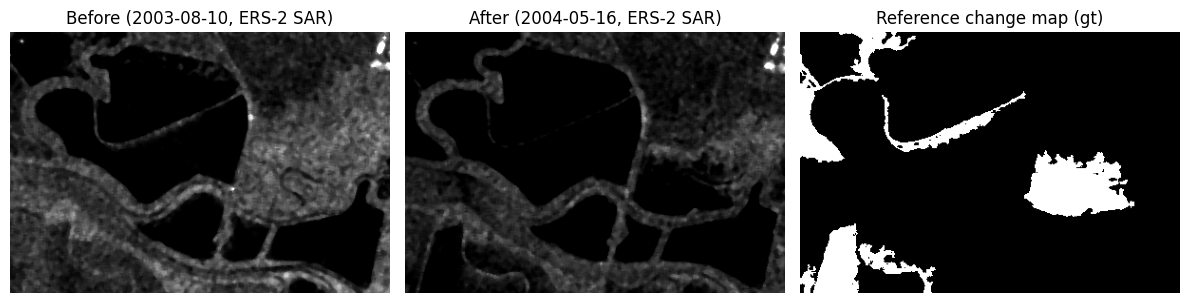

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].imshow(t1, cmap="gray"); axes[0].set_title("Before (2003-08-10, ERS-2 SAR)")
axes[1].imshow(t2, cmap="gray"); axes[1].set_title("After (2004-05-16, ERS-2 SAR)")
axes[2].imshow(gt, cmap="gray"); axes[2].set_title("Reference change map (gt)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Run GBF-CD on the sample

**What this cell does:** instantiates the authors' `GBF_CD` class with `ns = 4` (paper Table 4, San Francisco) and runs the full pipeline: per-modality max-normalization → spatial grid sampling → Gaussian local graphs with degree normalization → element-wise **minimum** fusion of the two graphs (paper Sec. 2.1: fusion by minimizing similarity) → one-shot Nyström eigendecomposition → selection of the scaled eigenvector that **maximizes mutual information** with the binarized forward/backward difference prior (paper Sec. 2.2) → Otsu thresholding into the final binary change map.

**日本語:** 著者の `GBF_CD` クラスを `ns=4`（論文 Table 4 のサンフランシスコ値）で実行します。正規化 → グリッドサンプリング → グラフ構築 → 2 グラフの要素別最小値融合 → Nyström 固有分解 → 事前信号との相互情報量が最大の固有ベクトル選択 → 大津法による二値化、という一連の処理です。

In [ ]:
N_SAMPLES = 4  # paper Table 4, San Francisco (grid rounding yields the actual count below)

g_nys = model.GBF_CD(t1, t2, N_SAMPLES)
change_map = g_nys.gbf_cd()

print("change map:", change_map.shape, change_map.dtype)
print("predicted changed pixels:", int(change_map.sum()),
      "({:.2f}% of scene)".format(100 * change_map.mean()))
print("reference  changed pixels:", int(gt.sum()),
      "({:.2f}% of scene)".format(100 * gt.mean()))

/content/generate_nystrom_graph.py:178: RuntimeWarning: invalid value encountered in divide
  prior1  = np.divide(self.data[0] - self.data[1], self.data[0] + self.data[1])
/usr/local/lib/python3.13/dist-packages/skimage/util/dtype.py:338: RuntimeWarning: invalid value encountered in cast
  return image_out.astype(dtype_out)
/content/generate_nystrom_graph.py:181: RuntimeWarning: invalid value encountered in divide
  prior2 = np.divide(self.data[1] - self.data[0], self.data[0] + self.data[1])


change map: (275, 400) bool
predicted changed pixels: 21263 (19.33% of scene)
reference  changed pixels: 13969 (12.70% of scene)


/content/generate_nystrom_graph.py:100: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  W_AA_sqrtinv = pinv(np.real_if_close(sqrtm(W_AA), tol=10**6))


## 6. Evaluation with the paper's metrics

**What this cell does:** computes exactly the metric set of the authors' `Functions/cohensKappa.m` — Missed Alarms (`MA`, % of true changes missed), False Alarms (`FA`, % of unchanged pixels flagged), Precision `P = TP/(TP+FN)`, Recall `R = TP/(TP+FP)`, Cohen's kappa, and Overall Error `OE` — plus the confusion matrix. Formulas follow the author file verbatim; kappa additionally cross-checked with `sklearn.metrics.cohen_kappa_score` (the authors' own `main.py` uses that function).

**日本語:** 著者の `cohensKappa.m` と同じ定義で MA・FA・Precision・Recall・Cohen's kappa・OE を計算し、混同行列とともに出力します。kappa は著者の `main.py` と同様に scikit-learn でも確認します。

In [ ]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import pandas as pd

C = confusion_matrix(gt.ravel(), change_map.ravel(), labels=[False, True])
tn, fp, fn, tp = C.ravel()

total_cd = int(gt.sum())            # true changed pixels
total_ncd = gt.size - total_cd      # true unchanged pixels

MA = fn / total_cd * 100            # missed alarms, % of true changes   (cohensKappa.m)
FA = fp / total_ncd * 100           # false alarms, % of unchanged      (cohensKappa.m)
P  = tp / (tp + fn)                 # precision                          (cohensKappa.m)
R  = tp / (tp + fp)                 # recall                             (cohensKappa.m)
OE = (fp + fn) / gt.size * 100      # overall error                      (cohensKappa.m)
kappa = cohen_kappa_score(change_map.ravel(), gt.ravel())

print("confusion matrix [rows=gt False/True, cols=pred False/True]:")
print(C, "\n")
metrics = pd.DataFrame(
    {"value": [MA, FA, P, R, kappa, OE]},
    index=["MA (missed alarms, %)", "FA (false alarms, %)",
           "Precision", "Recall", "Cohen's kappa", "OE (overall error, %)"],
)
metrics

confusion matrix [rows=gt False/True, cols=pred False/True]:
[[79827 16204]
 [ 8910  5059]] 



,value
"MA (missed alarms, %)",63.784093
"FA (false alarms, %)",16.873718
Precision,0.362159
Recall,0.237925
Cohen's kappa,0.158141
"OE (overall error, %)",22.830909


### 6.1 Error label map (prediction vs author reference)

**What this cell does:** renders the authors' `get_rgb_label_map` output — a per-pixel comparison of the GBF-CD prediction against the author-supplied reference `gt`: **green** = correct detections, **blue** = missed alarms, **red** = false alarms, white = correctly unchanged. This is the same visualization the authors' `main.py` produces.

**日本語:** 著者の `get_rgb_label_map` を用い、予測と参照 `gt` の画素比較を表示します。緑＝正検出、青＝見逃し（MA）、赤＝誤検出（FA）、白＝正しく非変化。

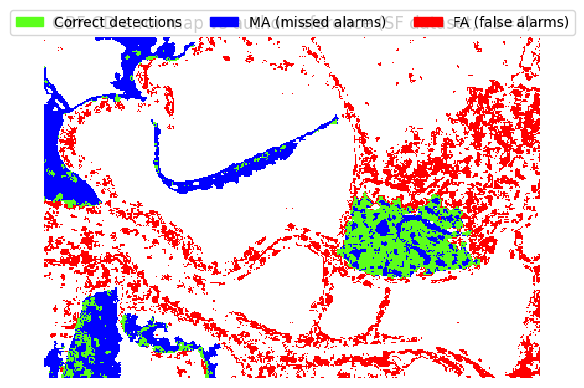

In [ ]:
import matplotlib.patches as mpatches

labeled_map, cmap = g_nys.get_rgb_label_map(gt)

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.imshow(labeled_map, cmap=cmap, interpolation="none", vmin=0, vmax=3)
handles = [
    mpatches.Patch(color="#5cff1c", label="Correct detections"),
    mpatches.Patch(color="blue", label="MA (missed alarms)"),
    mpatches.Patch(color="red", label="FA (false alarms)"),
]
ax.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.10))
ax.set_title("GBF-CD error map vs author reference (SF dataset, ns=4)")
ax.axis("off")
plt.show()

### 6.2 Export metrics

**What this cell does:** writes the metric table to a small CSV on the Colab VM (`/content/gbf_cd_sf_metrics.csv`) so the single-example result can be inspected or downloaded.

**日本語:** 単一サンプルの評価結果を `/content/gbf_cd_sf_metrics.csv` に CSV 保存します。

In [ ]:
metrics.round(6).to_csv("/content/gbf_cd_sf_metrics.csv", index_label="metric")
print(open("/content/gbf_cd_sf_metrics.csv").read())

metric,value
"MA (missed alarms, %)",63.784093
"FA (false alarms, %)",16.873718
Precision,0.362159
Recall,0.237925
Cohen's kappa,0.158141
"OE (overall error, %)",22.830909



## 7. Interpretation, differences, and validation record

**What this notebook establishes:** the authors' pinned Python implementation of GBF-CD runs end-to-end on their own `SF_dataset.mat` sample with the paper's per-dataset parameter (`ns = 4`, Table 4) and produces a binary change map, the paper's metric set, and the error label map. Values printed above were produced live on the Colab runtime; see the saved outputs.

**Differences from the paper / limitations:**
- This is **one scene**, not the paper's 14-scene benchmark; a single-example kappa is not the paper's reported dataset-level performance.
- The authors set `ns` and the kernel width by exhaustive grid search per dataset (paper Sec. 2.5.1, Table 4); the kernel width is computed internally by the released code, so only `ns` is supplied here (San Francisco `ns = 4` from Table 4).
- The biomass estimation branch is not reproduced (no public code and no public UAV images with destructive biomass ground truth).
- Documented code changes are limited to the three fixes in §3; the scientific operations are the authors' own.

**Validation record:** executed top-to-bottom on a fresh Google Colab CPU runtime (session of this reproduction run); all cells completed without errors. CPU and GPU paths are identical here (no GPU code exists in the method).

**日本語:** 本ノートブックは、著者固定版 Python 実装を `SF_dataset.mat` 1 例・`ns=4` で End-to-End 実行し、変化マップ・論文の指標セット・エラーマップを生成しました。14 シーン全体のベンチマークやバイオマス分岐は対象外です。実行は新規 Colab CPU ランタイムで検証済みです。

## References
- Jimenez-Sierra et al., *Remote Sensing* 2020, 12(17), 2683. https://doi.org/10.3390/rs12172683 (MDPI, CC-BY 4.0)
- Author code: https://github.com/DavidJimenezS/GBF-CD (commit `2c11fd15ae5371c6ef9a3b48a1c8489f85bcb116`); datasets in `Data/`; baselines in the linked repositories.
- Paper's parameter table (Table 4) and scene table (Table 1) read from the published open-access HTML.